In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#ERA DE RADIACIÓN
# ---------------------------------------------------------
# Parámetros del Modelo Normalizado
# ---------------------------------------------------------
f = 0.7257
p = 0.34  # Fracción de masa inicial (Debe ser menor a 'f')
z_i= 1e8
z_f= 1e4

# Parámetros del PBH
G = 6.67430e-8        # cm^3 g^-1 s^-2 (Antes e-11)
c = 2.998e10          # cm/s (Antes e8)
M_sol = 1.989e33      # g (Masa solar en gramos)
H0_km_s_Mpc = 67.4    # Constante de Hubble (Planck 2018)

# Convertir H0 a 1/s (CGS)
# 1 km = 10^5 cm
# 1 Mpc = 3.086e24 cm
H0 = (H0_km_s_Mpc * 1e5) / 3.086e24 

Omega_r0 = 9.0e-5     

v_inf = c / np.sqrt(3)

# ---------------------------------------------------------
# Ecuación Diferencial (Acreción Pura) CORREGIDA
# ---------------------------------------------------------
def dmu_dV(V, mu):
    """
    Ecuación (1) de los apuntes: dmu/dV = - (2p/f) * mu^2 * V
    """
    # Blindaje contra listas/arrays
    mu_val = np.atleast_1d(mu)[0]
    
    # CORRECCIÓN: Devolvemos una LISTA, no un número suelto
    return [- (2 * p / f) * (mu_val**2) * V]

# ---------------------------------------------------------
# Ejecución
# ---------------------------------------------------------
V_i = 1.0    # Presente al momento de formación (z = z_i)
V_f = (1.0 + z_f)/(1.0 + z_i)   # Futuro lejano (z mucho menor a z_i)

sol = solve_ivp(
    dmu_dV,
    [V_i, V_f],
    [1.0],       # La masa inicial normalizada es exactamente 1
    method='Radau',
    dense_output=True,
    rtol=1e-8,
    atol=1e-10
)

# ---------------------------------------------------------
# Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

plt.loglog(sol.t, sol.y[0], color='darkred', lw=3, label=f'Acreción ($p={p}$)')

# Invertimos el eje X porque V va de 1 (pasado) a 0 (futuro)
plt.gca().invert_xaxis()

plt.xlabel(r'Eedshift normalizado $V = (1+z)/(1+z_i)$', fontsize=12)
plt.ylabel(r'$\mu= M/M_i$', fontsize=12)
plt.title('Acreción de un PBH en la época de acreción ', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

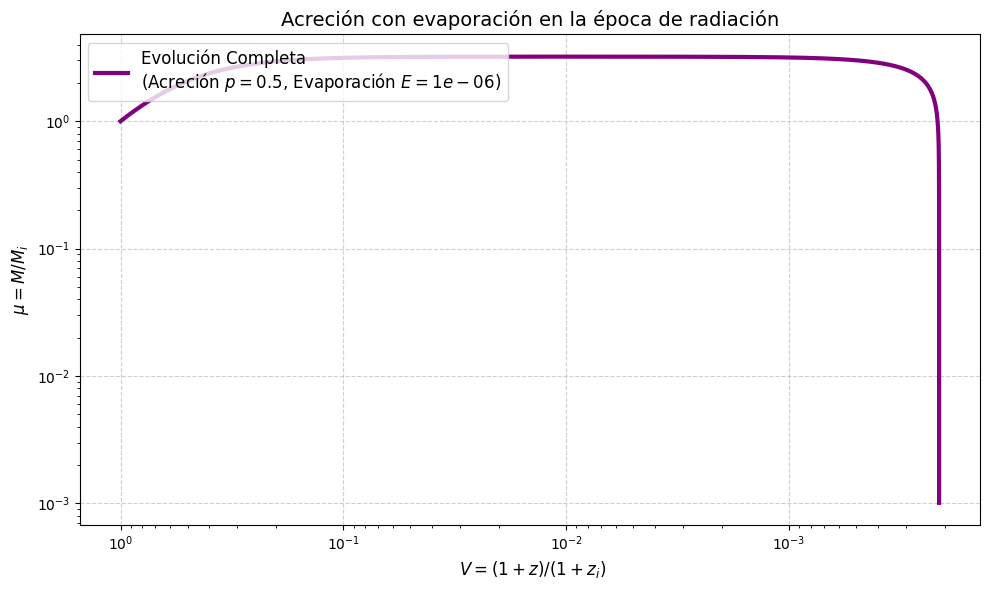

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------------------------------------------------
# Parámetros del Modelo Normalizado
# ---------------------------------------------------------
f = 0.7257
p = 0.5  # Término de fuerza de acreción
z_i= 1e8
z_f= 1e4
# Parámetros del PBH
G = 6.67430e-8        # cm^3 g^-1 s^-2 (Antes e-11)
c = 2.998e10          # cm/s (Antes e8)
hbar = 1.05457e-27 
M_sol = 1.989e33      # g (Masa solar en gramos)
H0_km_s_Mpc = 67.4    # Constante de Hubble (Planck 2018)
H0 = (67.4 * 1e5) / 3.0857e24 
Omega_r0 = 9.0e-5
K=(hbar*(c**4))/(3840*np.pi*(G**2))
E=1e-6
# ---------------------------------------------------------
# Ecuación Diferencial (Acreción + Evaporación)
# ---------------------------------------------------------
def dmu_dV_completa(V, mu):
    mu_val = mu[0]
    
    # Prevenir división por cero si la masa se hace negativa
    if mu_val <= 1e-10:
        return [0.0]
    
    # Término 1: Acreción (Crece la masa)
    acrecion = - (2 * p / f) * (mu_val**2) * V
    
    # Término 2: Evaporación (Reduce la masa)
    evaporacion = (E) / ((V**3) * (mu_val**2))
    
    return [acrecion + evaporacion]

# Evento para detener la integración cuando el PBH se evapora (mu = 0)
def pbh_evaporado(V, mu):
    return mu[0] - 1e-3
pbh_evaporado.terminal = True
pbh_evaporado.direction = -1

# ---------------------------------------------------------
# Ejecución
# ---------------------------------------------------------
V_i = 1.0    # Inicio (Formación)
V_f = (1.0 + z_f)/(1.0 + z_i)  # Futuro lejano 

sol = solve_ivp(
    dmu_dV_completa,
    [V_i, V_f],
    [1.0],       # Masa inicial normalizada
    method='Radau',
    events=pbh_evaporado,
    rtol=1e-8,
    atol=1e-10
)

# Insertar un NaN al final para que la gráfica corte abruptamente en la evaporación
V_sol = np.append(sol.t, sol.t[-1] - 1e-5)
mu_sol = np.append(sol.y[0], np.nan)

# ---------------------------------------------------------
# Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.loglog(V_sol, mu_sol, color='purple', lw=3, label=f'Evolución Completa\n(Acreción $p={p}$, Evaporación $E={E}$)')

plt.gca().invert_xaxis()

plt.xlabel(r' $V = (1+z)/(1+z_i)$', fontsize=12)
plt.ylabel(r'$\mu = M/M_i$', fontsize=12)
plt.title('Acreción con evaporación en la época de radiación', fontsize=14)

# Anotaciones explicativas

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

--------------------------------------------------
Redshift inicial (z_i): 1.0e+15
Tiempo de formación (t_i): 2.41e-11 segundos
Masa inicial (M_i): 6.82e+27 gramos
Constante calculada E: 2.41296e-69
--------------------------------------------------


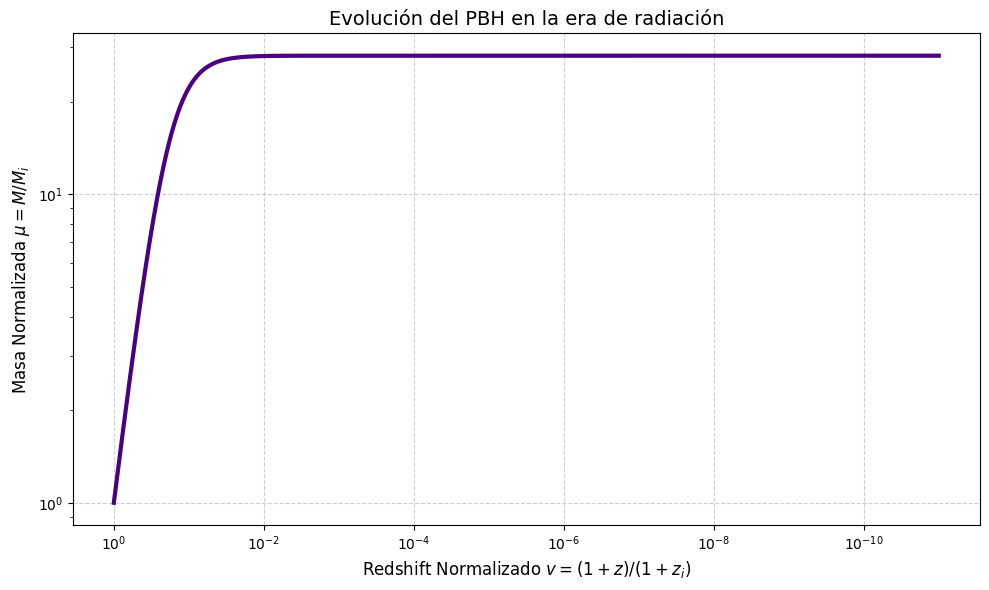

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#E calculado físicamente

# ---------------------------------------------------------
# 1. Constantes Físicas Universales (CGS)
# ---------------------------------------------------------
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_r0 = 9.0e-5     

# ---------------------------------------------------------
# 2. Parámetros del Agujero Negro (Física de Formación)
# ---------------------------------------------------------
# Redshift de formación (z_i muy alto para que la masa sea ligera y logre evaporarse)
z_i = 1e15
z_f= 1e4
p = 0.7  

# f = (8*sqrt(2)/3) * (c_inf / c)^3, donde c_inf = c/sqrt(3)
f = (8 * np.sqrt(2) / 3) * (1 / np.sqrt(3))**3 # Aprox 0.725774


# Tiempo físico de formación (t_i) en era de radiación
t_i = 1.0 / (2 * H0 * np.sqrt(Omega_r0) * (1 + z_i)**2)

# Masa del horizonte al tiempo t_i
M_Hi = (c**3 * t_i) / G
M_c=f*M_Hi

# Masa inicial del PBH
M_i = (p/f) * M_c

# Constante de evaporación K
K = (hbar * c**4) / (3840 * np.pi * G**2)

# ¡Cálculo de E derivado en tu ecuación diferencial!
E = (2 * K * t_i) / (M_i**3)

print("-" * 50)
print(f"Redshift inicial (z_i): {z_i:.1e}")
print(f"Tiempo de formación (t_i): {t_i:.2e} segundos")
print(f"Masa inicial (M_i): {M_i:.2e} gramos")
print(f"Constante calculada E: {E:.5e}")
print("-" * 50)

# ---------------------------------------------------------
# 4. Ecuación Diferencial (Ecuación 2 de los apuntes)
# ---------------------------------------------------------
def dmu_dv(v, mu):
    mu_val = np.atleast_1d(mu)[0]
    
    if mu_val <= 1e-5:
        return [0.0]
    
    term_evap = E / ((v**3) * (mu_val**2))
    term_acc = (2 * p / f) * (mu_val**2) * v
    
    return [term_evap - term_acc]

# Evento para detener la integración cuando el PBH se evapora
def evaporacion_total(v, mu):
    return mu[0] - 1e-3  
evaporacion_total.terminal = True
evaporacion_total.direction = -1

# ---------------------------------------------------------
# 5. Ejecución del Solucionador
# ---------------------------------------------------------
v_i = 1.0    
v_f = (1.0 + z_f)/(1.0 + z_i)  

sol = solve_ivp(
    dmu_dv,
    [v_i, v_f],
    [1.0],       
    method='Radau',
    events=evaporacion_total,
    rtol=1e-8,
    atol=1e-10
)

# Corte visual limpio
v_sol = np.append(sol.t, sol.t[-1] - 1e-11)
mu_sol = np.append(sol.y[0], np.nan)

# ---------------------------------------------------------
# 6. Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.loglog(v_sol, mu_sol, color='indigo', lw=3, label=f'Ecuación (2)\n$p={p}$, $E={E:.1e}$')

plt.gca().invert_xaxis()

plt.xlabel(r'Redshift Normalizado $v = (1+z)/(1+z_i)$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M/M_i$', fontsize=12)
plt.title('Evolución del PBH en la era de radiación', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
#plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

--------------------------------------------------
Redshift inicial (z_i): 1.0e+08
Tiempo de formación (t_i): 2.41e+03 segundos
Masa inicial fijada (M_i): 5.00e+09 gramos
Constante calculada E: 6.11964e-01
--------------------------------------------------


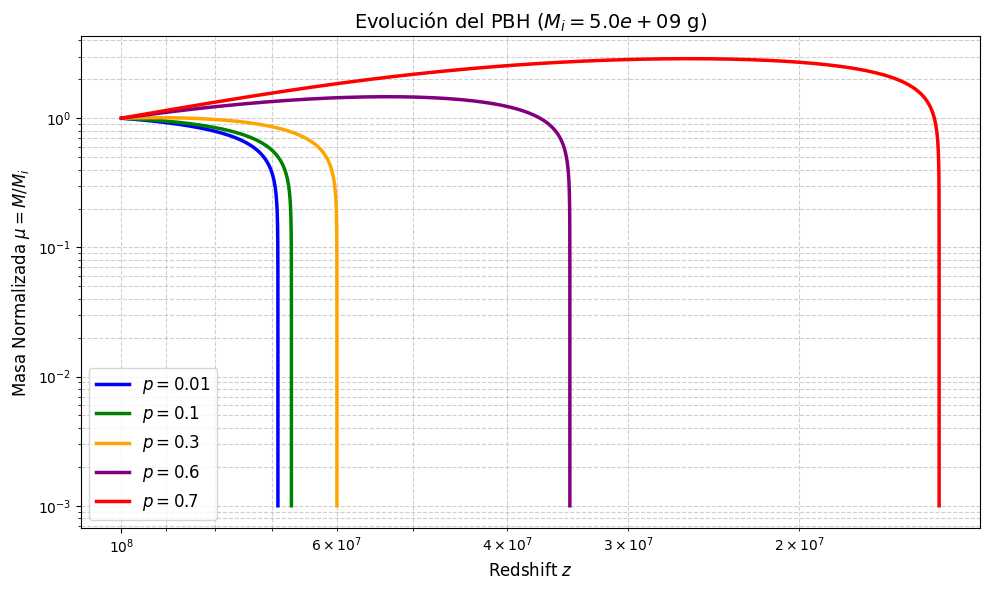

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------------------------------------------------
# 1. Constantes Físicas Universales (CGS)
# ---------------------------------------------------------
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_r0 = 9.0e-5     

# ---------------------------------------------------------
# 2. Parámetros del Agujero Negro y Simulación
# ---------------------------------------------------------
z_i = 1e8
z_f = 1e4

# 1. Tú defines la masa inicial directamente (en gramos)
M_i = 5e9 

# 2. Array de diferentes valores de p (fuerza de acreción)
p_array = [0.01, 0.1, 0.3, 0.6, 0.7]
colores = ['blue', 'green', 'orange', 'purple', 'red']

# f = (8*sqrt(2)/3) * (c_inf / c)^3, donde c_inf = c/sqrt(3)
f = (8 * np.sqrt(2) / 3) * (1 / np.sqrt(3))**3 # Aprox 0.725774

# Tiempo físico de formación (t_i)
t_i = 1.0 / (2 * H0 * np.sqrt(Omega_r0) * (1 + z_i)**2)

# Constante de evaporación K
K = (hbar * c**4) / (3840 * np.pi * G**2)

# ¡Cálculo de E usando tu masa manual!
E = (2 * K * t_i) / (M_i**3)

print("-" * 50)
print(f"Redshift inicial (z_i): {z_i:.1e}")
print(f"Tiempo de formación (t_i): {t_i:.2e} segundos")
print(f"Masa inicial fijada (M_i): {M_i:.2e} gramos")
print(f"Constante calculada E: {E:.5e}")
print("-" * 50)

# ---------------------------------------------------------
# 3. Configuración y Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

v_i = 1.0    
v_f = (1.0 + z_f)/(1.0 + z_i)  

# Iteramos sobre cada valor de p
for p_val, color in zip(p_array, colores):
    
    # Ecuación Diferencial en variables normalizadas
    def dmu_dv(v, mu, p_current=p_val):
        mu_val = np.atleast_1d(mu)[0]
        
        if mu_val <= 1e-5:
            return [0.0]
        
        term_evap = E / ((v**3) * (mu_val**2))
        term_acc = (2 * p_current / f) * (mu_val**2) * v
        
        return [term_evap - term_acc]

    # Evento para detener la integración cuando se evapora
    def evaporacion_total(v, mu):
        return mu[0] - 1e-3  
    evaporacion_total.terminal = True
    evaporacion_total.direction = -1

    # Ejecución del Solucionador
    sol = solve_ivp(
        dmu_dv,
        [v_i, v_f],
        [1.0],       
        method='Radau',
        events=evaporacion_total,
        rtol=1e-8,
        atol=1e-10
    )

    v_sol = sol.t
    mu_sol = sol.y[0]
    
    # Si el PBH se evaporó, añadimos NaN para cortar la línea
    if sol.status == 1 and mu_sol[-1] < 1e-2:
        v_sol = np.append(v_sol, v_sol[-1] - 1e-11)
        mu_sol = np.append(mu_sol, np.nan)

    # --- ¡NUEVO!: CONVERTIMOS 'v' DE REGRESO AL REDSHIFT 'z' ---
    # Despejamos z de la ecuación v = (1+z)/(1+z_i)
    z_sol = v_sol * (1.0 + z_i) - 1.0

    # Graficamos usando z_sol en el eje X
    plt.loglog(z_sol, mu_sol, color=color, lw=2.5, label=f'$p = {p_val}$')

# ---------------------------------------------------------
# 4. Estética de la Gráfica
# ---------------------------------------------------------
# Invertimos el eje X porque el tiempo avanza conforme el redshift z disminuye
plt.gca().invert_xaxis()

plt.xlabel(r'Redshift $z$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M/M_i$', fontsize=12)
plt.title(f'Evolución del PBH ($M_i = {M_i:.1e}$ g)', fontsize=14)

plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()

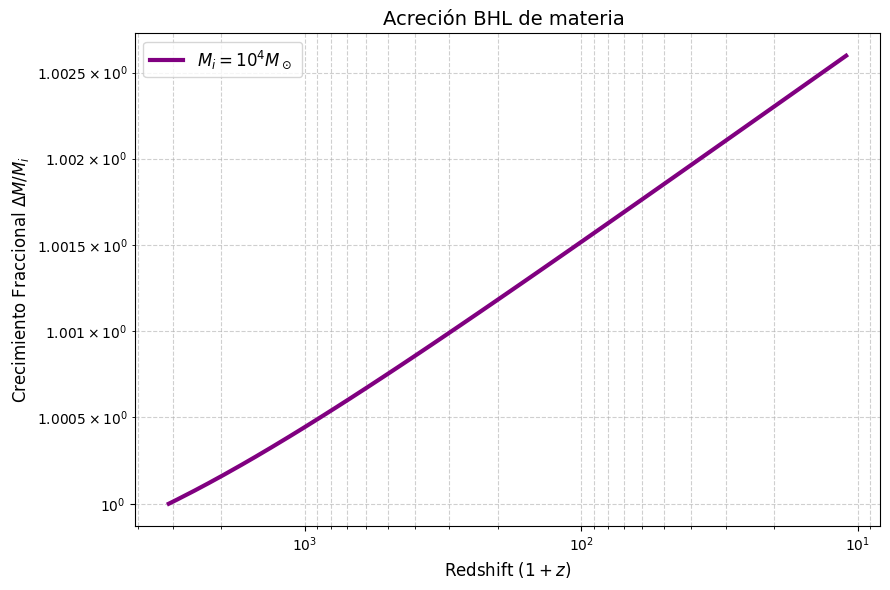

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#Acreción BHL de materia
# ---------------------------------------------------------
# 1. Constantes Físicas y Cosmológicas (CGS)
# ---------------------------------------------------------
G = 6.67430e-8        
c = 2.99792e10        
M_sol = 1.989e33
m_H = 1.67e-24        # Masa del átomo de hidrógeno en gramos

H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_m0 = 0.32       
Omega_r0 = 9.4e-5     
Omega_L0 = 0.68       

# ---------------------------------------------------------
# 2. Funciones del Modelo BHL Cosmológico (Sec. 3)
# ---------------------------------------------------------
def cosmic_velocities(z):
    """
    Ecuaciones 3.7 y 3.8: Perfiles de velocidad de SPIK20.
    Devuelve c_s y v_pbh en cm/s.
    """
    # Velocidad del sonido (Eq 3.7) -> 6 km/s convertidos a cm/s
    c_s = 6e5 * np.sqrt((1 + z) / 1000.0)
    
    # Velocidad peculiar del PBH (Eq 3.8) -> 30 km/s convertidos a cm/s
    factor = min(1.0, (1 + z) / 1000.0)
    v_pbh = 0
    
    # Velocidad efectiva
    v_eff = np.sqrt(v_pbh**2 + c_s**2)
    return c_s, v_pbh, v_eff

def lambda_efficiency(z, M, v_eff):
    """
    Calcula la eficiencia de acreción lambda (Eqs. 3.4 - 3.6).
    """
    # Fracción de electrones libres post-recombinación (asumida en el paper)
    x_e = 1e-3 
    
    # Convertimos v_eff a km/s solo para esta fórmula empírica
    v_eff_km_s = v_eff / 1e5
    
    # Ecuación 3.6: Viscosidad del gas (beta_hat)
    term1 = (M / (1e4 * M_sol))
    term2 = ((1 + z) / 1000.0)**1.5
    term3 = (v_eff_km_s / 5.74)**(-3)
    term4 = 0.257 + 1.45 * (x_e / 0.01) * ((1 + z) / 1000.0)**2.5
    beta_hat = term1 * term2 * term3 * term4
    
    # Ecuación 3.5: Radio crítico normalizado
    x_cr = (-1.0 + np.sqrt(1.0 + beta_hat)) / beta_hat
    
    # Ecuación 3.4: Eficiencia Lambda
    lam = np.exp(4.5 / (3.0 + beta_hat**0.75)) * (x_cr**2)
    return lam

def dM_dz_BHL(z, M):
    """
    Tasa de cambio de masa respecto al redshift dM/dz.
    """
    M_val = np.atleast_1d(M)[0]
    
    # 1. Parámetros del gas a este redshift
    n_gas = 200.0 * ((1 + z) / 1000.0)**3    # Eq 3.1 (cm^-3)
    rho_b = m_H * n_gas                      # Eq 3.2 (g/cm^3)
    
    c_s, v_pbh, v_eff = cosmic_velocities(z)
    lam = lambda_efficiency(z, M_val, v_eff)
    
    # 2. Tasa de Acreción BHL (Eq 3.3)
    r_B0 = (G * M_val) / (v_eff**2)
    dM_dt = 4 * np.pi * lam * rho_b * v_eff * (r_B0**2)
    
    # 3. Conversión de tiempo a redshift dt/dz
    H_z = H0 * np.sqrt(Omega_r0*(1+z)**4 + Omega_m0*(1+z)**3 + Omega_L0)
    dt_dz = -1.0 / ((1 + z) * H_z)
    
    # Regla de la cadena: dM/dz = dM/dt * dt/dz
    return [dM_dt * dt_dz]

# ---------------------------------------------------------
# 3. Simulación
# ---------------------------------------------------------
z_start = 3100.0   # Recombinación
z_end = 10.0       # Fin del régimen lineal

# Probaremos con un PBH masivo (10,000 M_sol) para ver un cambio notable
M_initial = 100 * M_sol

sol = solve_ivp(
    dM_dz_BHL,
    [z_start, z_end],
    [M_initial],
    method='Radau',
    rtol=1e-8,
    atol=1e-10
)

z_sol = sol.t
M_sol_res = sol.y[0]

# ---------------------------------------------------------
# 4. Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

incremento_fraccional = (M_sol_res / M_initial)

plt.loglog(1+z_sol, incremento_fraccional, color='purple', lw=3, 
           label=r'$M_i = 10^4 M_\odot$ ')

plt.gca().invert_xaxis() 

plt.xlabel(r'Redshift $(1+z)$', fontsize=12)
plt.ylabel(r'Crecimiento Fraccional $\Delta M / M_i$', fontsize=12)
plt.title('Acreción BHL de materia ', fontsize=14)

plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

--------------------------------------------------
--- INICIANDO FASE 1: RADIACIÓN ---
Redshift inicial (z_i): 1.0e+08
Masa de formación (M_i): 6.67e+41 gramos
--------------------------------------------------
--- INICIANDO FASE 2: MATERIA ---
Sobrevivió con masa: 1.88e+43 gramos
--------------------------------------------------
--- RESULTADO FINAL DE LA SIMULACIÓN ---
¡El PBH sobrevivió hasta z=10.0!
Masa final: 4.5409e+43 gramos
Masa final: 2.2830e+10 Masas Solares
Crecimiento total (M_final / M_i): 68.0598 veces su masa inicial
--------------------------------------------------


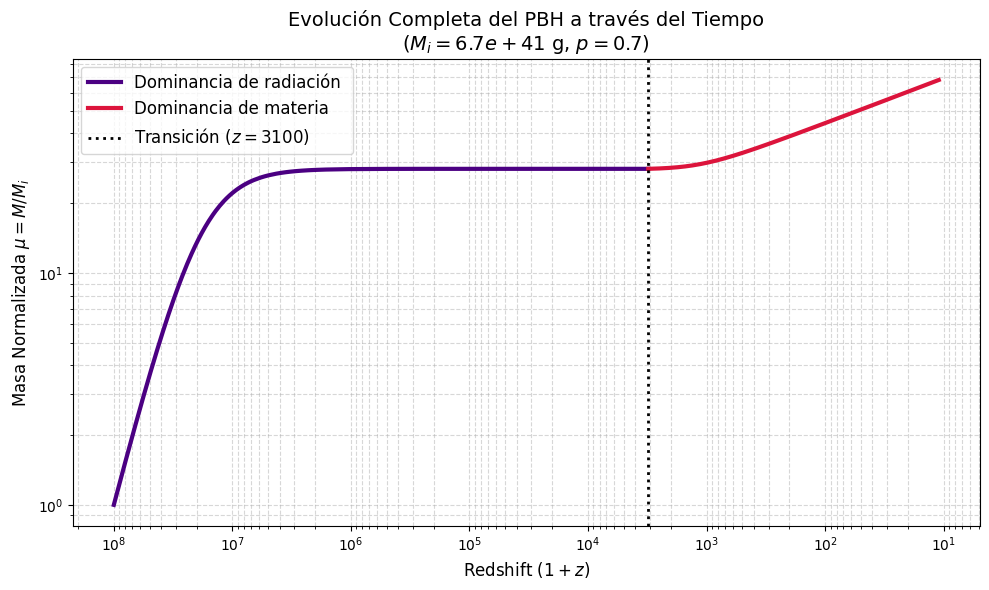

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#Acreción de radiación y materia utilizando un modelo de acreción BHL.

# =========================================================
# 0. Constantes Globales (CGS)
# =========================================================
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
M_sol = 1.989e33
m_H = 1.67e-24        
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_m0 = 0.32       
Omega_r0 = 9.4e-5     
Omega_L0 = 0.68       

K = (hbar * c**4) / (3840 * np.pi * G**2)

# =========================================================
# FASE 1: ERA DE RADIACIÓN (Tu código)
# =========================================================
z_i = 1e8
z_f_rad = 3100
p = 0.7  

f = (8 * np.sqrt(2) / 3) * (1 / np.sqrt(3))**3 

# Tiempo físico de formación (t_i)
t_i = 1.0 / (2 * H0 * np.sqrt(Omega_r0) * (1 + z_i)**2)

# Masas iniciales y Constante E
M_Hi = (c**3 * t_i) / G
M_c = f * M_Hi
M_i = (p/f) * M_c
#M_i=1e8
E = (2 * K * t_i) / (M_i**3)

print("-" * 50)
print("--- INICIANDO FASE 1: RADIACIÓN ---")
print(f"Redshift inicial (z_i): {z_i:.1e}")
print(f"Masa de formación (M_i): {M_i:.2e} gramos")

def dmu_dv(v, mu):
    mu_val = np.atleast_1d(mu)[0]
    if mu_val <= 1e-5:
        return [0.0]
    term_evap = E / ((v**3) * (mu_val**2))
    term_acc = (2 * p / f) * (mu_val**2) * v
    return [term_evap - term_acc]

def evaporacion_rad(v, mu):
    return mu[0] - 1e-3  
evaporacion_rad.terminal = True
evaporacion_rad.direction = -1

v_i = 1.0    
v_f = (1.0 + z_f_rad)/(1.0 + z_i)  

sol_rad = solve_ivp(
    dmu_dv,
    [v_i, v_f],
    [1.0],       
    method='Radau',
    events=evaporacion_rad,
    rtol=1e-8,
    atol=1e-10
)

# Convertir 'v' al Redshift (1+z)
v_sol_rad = sol_rad.t
l_plus_z_rad = v_sol_rad * (1.0 + z_i)
mu_sol_rad = sol_rad.y[0]

# =========================================================
# TRANSICIÓN DE ERAS
# =========================================================
pbh_sobrevivio = True
if sol_rad.status == 1 or mu_sol_rad[-1] < 1e-2:
    pbh_sobrevivio = False
    print("¡El PBH se evaporó durante la era de radiación!")

# =========================================================
# FASE 2: ERA DE MATERIA (Modelo BHL + Evaporación)
# =========================================================
if pbh_sobrevivio:
    # La masa al inicio de la era de materia es la masa final de la era de radiación
    M_start_mat = mu_sol_rad[-1] * M_i
    z_start_mat = z_f_rad
    z_end_mat = 10.0
    
    print("-" * 50)
    print("--- INICIANDO FASE 2: MATERIA ---")
    print(f"Sobrevivió con masa: {M_start_mat:.2e} gramos")
    
    def cosmic_velocities(z):
        c_s = 6e5 * np.sqrt((1 + z) / 1000.0)
        factor = min(1.0, (1 + z) / 1000.0)
        #v_pbh =30e5 * factor
        v_pbh=0
        v_eff = np.sqrt(v_pbh**2 + c_s**2)
        return c_s, v_pbh, v_eff

    def lambda_efficiency(z, M, v_eff):
        x_e = 1e-3 
        v_eff_km_s = v_eff / 1e5
        term1 = (M / (1e4 * M_sol))
        term2 = ((1 + z) / 1000.0)**1.5
        term3 = (v_eff_km_s / 5.74)**(-3)
        term4 = 0.257 + 1.45 * (x_e / 0.01) * ((1 + z) / 1000.0)**2.5
        beta_hat = term1 * term2 * term3 * term4
        
        if beta_hat < 1e-12: # Para masas pequeñas, previene error numérico
            return 1.0
        
        x_cr = (-1.0 + np.sqrt(1.0 + beta_hat)) / beta_hat
        lam = np.exp(4.5 / (3.0 + beta_hat**0.75)) * (x_cr**2)
        return lam

    def dM_dz_mat(z, M):
        M_val = np.atleast_1d(M)[0]
        if M_val <= 1e-5:
            return [0.0]
        
        # Acreción BHL
        n_gas = 200.0 * ((1 + z) / 1000.0)**3    
        rho_b = m_H * n_gas                      
        c_s, v_pbh, v_eff = cosmic_velocities(z)
        lam = lambda_efficiency(z, M_val, v_eff)
        r_B0 = (G * M_val) / (v_eff**2)
        dM_dt_acc = 4 * np.pi * lam * rho_b * v_eff * (r_B0**2)
        
        # Evaporación de Hawking
        dM_dt_evap = K / (M_val**2)
        
        # Tasa de cambio total
        dM_dt_total = dM_dt_acc - dM_dt_evap
        
        # dt/dz 
        H_z = H0 * np.sqrt(Omega_r0*(1+z)**4 + Omega_m0*(1+z)**3 + Omega_L0)
        dt_dz = -1.0 / ((1 + z) * H_z)
        
        return [dM_dt_total * dt_dz]

    def evaporacion_mat(z, M):
        return M[0] - 1e-3
    evaporacion_mat.terminal = True

    sol_mat = solve_ivp(
        dM_dz_mat,
        [z_start_mat, z_end_mat],
        [M_start_mat],
        method='Radau',
        events=evaporacion_mat,
        rtol=1e-8,
        atol=1e-10
    )
    
    z_sol_mat = sol_mat.t
    M_sol_mat = sol_mat.y[0]
    
    print("-" * 50)
    print("--- RESULTADO FINAL DE LA SIMULACIÓN ---")
    # Limpieza visual si el PBH se evapora en la era de materia
    if sol_mat.status == 1 and M_sol_mat[-1] < 1e-2:
        z_sol_mat = np.append(z_sol_mat, z_sol_mat[-1] - 1e-6)
        M_sol_mat = np.append(M_sol_mat, np.nan)
        print("¡El PBH se evaporó completamente durante la era de materia!")
        print(f"Masa final en z={z_end_mat}: 0.0 gramos")
    else:
        M_final_g = M_sol_mat[-1]
        M_final_sol = M_final_g / M_sol
        print(f"¡El PBH sobrevivió hasta z={z_end_mat}!")
        print(f"Masa final: {M_final_g:.4e} gramos")
        print(f"Masa final: {M_final_sol:.4e} Masas Solares")
        print(f"Crecimiento total (M_final / M_i): {M_final_g / M_i:.4f} veces su masa inicial")
    print("-" * 50)

    # Extraemos (1+z) y volvemos a normalizar la masa con la M_i ORIGINAL
    l_plus_z_mat = 1.0 + z_sol_mat
    mu_sol_mat = M_sol_mat / M_i
    
# =========================================================
# GRÁFICA UNIFICADA
# =========================================================
plt.figure(figsize=(10, 6))

# Trazamos la Era de Radiación
plt.loglog(l_plus_z_rad, mu_sol_rad, color='indigo', lw=3, label=f'Dominancia de radiación ')

# Trazamos la Era de Materia si sobrevivió
if pbh_sobrevivio:
    plt.loglog(l_plus_z_mat, mu_sol_mat, color='crimson', lw=3, linestyle='-', label='Dominancia de materia')

# Invertimos el eje X para el flujo temporal clásico
plt.gca().invert_xaxis()

plt.xlabel(r'Redshift $(1+z)$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M/M_{i}$', fontsize=12)
plt.title(f'Evolución Completa del PBH a través del Tiempo\n($M_i = {M_i:.1e}$ g, $p={p}$)', fontsize=14)

plt.axvline(x=z_f_rad, color='black', linestyle=':', lw=2, label=f'Transición ($z={z_f_rad}$)')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

--------------------------------------------------
INICIANDO SIMULACIONES POR VALOR DE 'p'
--------------------------------------------------

Simulando p = 0.1,  M_i = 9.53e+40 g
  -> Resultado: Sobrevivió hasta el final (M_final = 2.61e+41 g).

Simulando p = 0.4,  M_i = 3.81e+41 g
  -> Resultado: Sobrevivió hasta el final (M_final = 2.04e+42 g).

Simulando p = 0.6,  M_i = 5.72e+41 g
  -> Resultado: Sobrevivió hasta el final (M_final = 7.95e+42 g).

Simulando p = 0.7,  M_i = 6.67e+41 g
  -> Resultado: Sobrevivió hasta el final (M_final = 4.54e+43 g).

Simulando p = 0.72,  M_i = 6.86e+41 g
  -> Resultado: Sobrevivió hasta el final (M_final = 2.09e+44 g).
--------------------------------------------------


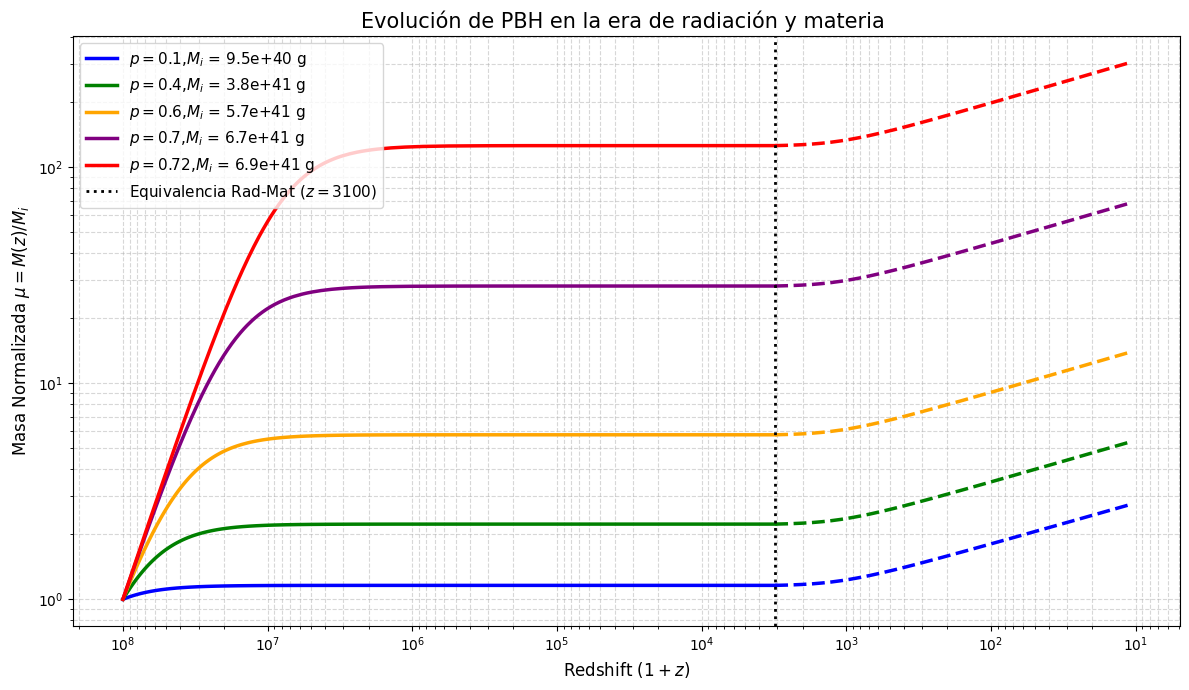

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#Acreción BHL con diferentes p
# =========================================================
# 0. Constantes Globales (CGS)
# =========================================================
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
M_sol = 1.989e33
m_H = 1.67e-24        
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_m0 = 0.32       
Omega_r0 = 9.4e-5     
Omega_L0 = 0.68       

K = (hbar * c**4) / (3840 * np.pi * G**2)

# =========================================================
# 1. Parámetros de Simulación Base
# =========================================================
z_i = 1e8
z_f_rad = 3100

# Arreglo de valores p para iterar
p_array = [0.1, 0.4, 0.6, 0.7, 0.72]
colores = ['blue', 'green', 'orange', 'purple', 'red']

f = (8 * np.sqrt(2) / 3) * (1 / np.sqrt(3))**3 
t_i = 1.0 / (2 * H0 * np.sqrt(Omega_r0) * (1 + z_i)**2)
M_Hi = (c**3 * t_i) / G
M_c = f * M_Hi

# Funciones de la Era de Materia (BHL)
def cosmic_velocities(z):
    c_s = 6e5 * np.sqrt((1 + z) / 1000.0)
    factor = min(1.0, (1 + z) / 1000.0)
    #v_pbh = 30e5 * factor
    v_pbh=0
    v_eff = np.sqrt(v_pbh**2 + c_s**2)
    return c_s, v_pbh, v_eff

def lambda_efficiency(z, M, v_eff):
    x_e = 1e-3 
    v_eff_km_s = v_eff / 1e5
    term1 = (M / (1e4 * M_sol))
    term2 = ((1 + z) / 1000.0)**1.5
    term3 = (v_eff_km_s / 5.74)**(-3)
    term4 = 0.257 + 1.45 * (x_e / 0.01) * ((1 + z) / 1000.0)**2.5
    beta_hat = term1 * term2 * term3 * term4
    
    if beta_hat < 1e-12:
        return 1.0
    
    x_cr = (-1.0 + np.sqrt(1.0 + beta_hat)) / beta_hat
    lam = np.exp(4.5 / (3.0 + beta_hat**0.75)) * (x_cr**2)
    return lam

def evaporacion_total(t, y):
    return y[0] - 1e-3
evaporacion_total.terminal = True
evaporacion_total.direction = -1

# =========================================================
# 2. Configuración de Gráfica
# =========================================================
plt.figure(figsize=(12, 7))

print("-" * 50)
print("INICIANDO SIMULACIONES POR VALOR DE 'p'")
print("-" * 50)

# =========================================================
# 3. Bucle Principal sobre 'p'
# =========================================================
for p_val, color in zip(p_array, colores):
    
    # 3.1 Condiciones Iniciales para este p
    M_i_val = (p_val/f) * M_c
    #M_i_val=1e12
    E_val = (2 * K * t_i) / (M_i_val**3)
    
    print(f"\nSimulando p = {p_val},  M_i = {M_i_val:.2e} g")
    
    # --- FASE 1: RADIACIÓN ---
    def dmu_dv_rad(v, mu):
        mu_val = np.atleast_1d(mu)[0]
        if mu_val <= 1e-5:
            return [0.0]
        term_evap = E_val / ((v**3) * (mu_val**2))
        term_acc = (2 * p_val / f) * (mu_val**2) * v
        return [term_evap - term_acc]

    v_i = 1.0    
    v_f = (1.0 + z_f_rad)/(1.0 + z_i)  

    sol_rad = solve_ivp(
        dmu_dv_rad,
        [v_i, v_f],
        [1.0],       
        method='Radau',
        events=evaporacion_total,
        rtol=1e-8,
        atol=1e-10
    )

    v_sol_rad = sol_rad.t
    l_plus_z_rad = v_sol_rad * (1.0 + z_i)
    mu_sol_rad = sol_rad.y[0]
    
    # Graficar radiación (línea continua)
    plt.loglog(l_plus_z_rad, mu_sol_rad, color=color, lw=2.5, label=f'$p={p_val}$,$M_i$ = {M_i_val:.1e} g')
    
    pbh_sobrevivio = True
    if sol_rad.status == 1 or mu_sol_rad[-1] < 1e-2:
        pbh_sobrevivio = False
        print(f"  -> Resultado: Evaporado en radiación.")
        
    # --- FASE 2: MATERIA ---
    if pbh_sobrevivio:
        M_start_mat = mu_sol_rad[-1] * M_i_val
        z_start_mat = z_f_rad
        z_end_mat = 10.0
        
        def dM_dz_mat(z, M):
            M_val = np.atleast_1d(M)[0]
            if M_val <= 1e-5:
                return [0.0]
            
            n_gas = 200.0 * ((1 + z) / 1000.0)**3    
            rho_b = m_H * n_gas                      
            c_s, v_pbh, v_eff = cosmic_velocities(z)
            lam = lambda_efficiency(z, M_val, v_eff)
            r_B0 = (G * M_val) / (v_eff**2)
            
            dM_dt_acc = 4 * np.pi * lam * rho_b * v_eff * (r_B0**2)
            dM_dt_evap = K / (M_val**2)
            dM_dt_total = dM_dt_acc - dM_dt_evap
            
            H_z = H0 * np.sqrt(Omega_r0*(1+z)**4 + Omega_m0*(1+z)**3 + Omega_L0)
            dt_dz = -1.0 / ((1 + z) * H_z)
            
            return [dM_dt_total * dt_dz]

        sol_mat = solve_ivp(
            dM_dz_mat,
            [z_start_mat, z_end_mat],
            [M_start_mat],
            method='Radau',
            events=evaporacion_total,
            rtol=1e-8,
            atol=1e-10
        )
        
        z_sol_mat = sol_mat.t
        M_sol_mat = sol_mat.y[0]
        
        if sol_mat.status == 1 and M_sol_mat[-1] < 1e-2:
            z_sol_mat = np.append(z_sol_mat, z_sol_mat[-1] - 1e-6)
            M_sol_mat = np.append(M_sol_mat, np.nan)
            print(f"  -> Resultado: Sobrevivió radiación, pero se evaporó en materia.")
        else:
            print(f"  -> Resultado: Sobrevivió hasta el final (M_final = {M_sol_mat[-1]:.2e} g).")

        l_plus_z_mat = 1.0 + z_sol_mat
        mu_sol_mat = M_sol_mat / M_i_val
        
        # Graficar materia (línea punteada, mismo color, no la agregamos a la leyenda para no duplicar)
        plt.loglog(l_plus_z_mat, mu_sol_mat, color=color, lw=2.5, linestyle='--')

print("-" * 50)

# =========================================================
# 4. Detalles Visuales de la Gráfica
# =========================================================
plt.gca().invert_xaxis()

plt.xlabel(r'Redshift $(1+z)$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M(z)/M_{i}$', fontsize=12)
plt.title(f'Evolución de PBH en la era de radiación y materia ', fontsize=15)

plt.axvline(x=z_f_rad, color='black', linestyle=':', lw=2, label=f'Equivalencia Rad-Mat ($z={z_f_rad}$)')

plt.grid(True, which="both", linestyle='--', alpha=0.5)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig("accretbhl1.png")
plt.show()

--------------------------------------------------
INICIANDO SIMULACIONES POR VALOR DE 'p'
--------------------------------------------------
Simulando p = 0.1 (M_i = 9.53e+40 g)
Simulando p = 0.4 (M_i = 3.81e+41 g)
Simulando p = 0.6 (M_i = 5.72e+41 g)
Simulando p = 0.7 (M_i = 6.67e+41 g)
Simulando p = 0.72 (M_i = 6.86e+41 g)
--------------------------------------------------


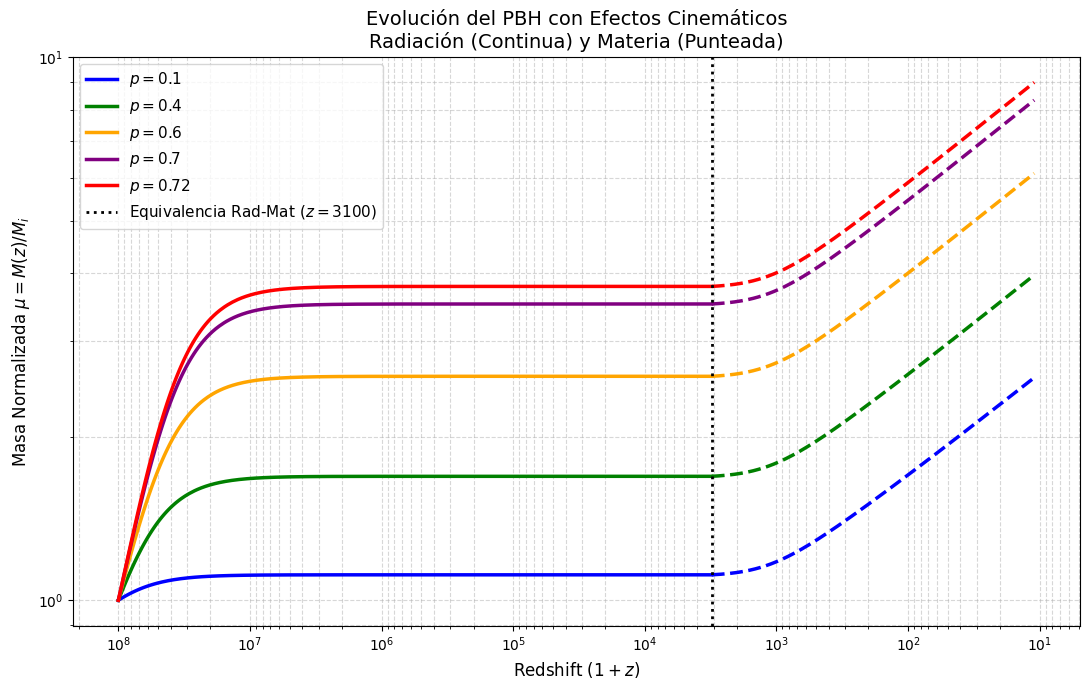

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#PBH con velocidad inicial
# =========================================================
# 0. Constantes Globales (CGS)
# =========================================================
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
M_sol = 1.989e33
m_H = 1.67e-24        
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_m0 = 0.32       
Omega_r0 = 9.4e-5     
Omega_L0 = 0.68       

K = (hbar * c**4) / (3840 * np.pi * G**2)

# =========================================================
# 1. Parámetros de Simulación Base
# =========================================================
z_i = 1e8
z_f_rad = 3100

# Arreglo de valores p para iterar
p_array = [0.1, 0.4, 0.6, 0.7, 0.72]
colores = ['blue', 'green', 'orange', 'purple', 'red']

# Física base de la radiación
c_s_rad = c / np.sqrt(3)
t_i = 1.0 / (2 * H0 * np.sqrt(Omega_r0) * (1 + z_i)**2)
M_Hi = (c**3 * t_i) / G

# --- ¡NUEVO!: Velocidad peculiar inicial del PBH ---
# Le damos un "kick" inicial relativista (40% de la velocidad de la luz)
# para que su efecto sea visible en la gráfica.
v_pbh_inicial = 0.4*c

# Funciones de la Era de Materia (BHL)
def cosmic_velocities_mat(z):
    c_s = 6e5 * np.sqrt((1 + z) / 1000.0)
    factor = min(1.0, (1 + z) / 1000.0)
    v_pbh = 30e5 * factor
    v_eff = np.sqrt(v_pbh**2 + c_s**2)
    return c_s, v_pbh, v_eff

def lambda_efficiency(z, M, v_eff):
    x_e = 1e-3 
    v_eff_km_s = v_eff / 1e5
    term1 = (M / (1e4 * M_sol))
    term2 = ((1 + z) / 1000.0)**1.5
    term3 = (v_eff_km_s / 5.74)**(-3)
    term4 = 0.257 + 1.45 * (x_e / 0.01) * ((1 + z) / 1000.0)**2.5
    beta_hat = term1 * term2 * term3 * term4
    
    if beta_hat < 1e-12:
        return 1.0
    
    x_cr = (-1.0 + np.sqrt(1.0 + beta_hat)) / beta_hat
    lam = np.exp(4.5 / (3.0 + beta_hat**0.75)) * (x_cr**2)
    return lam

def evaporacion_total(t, y):
    return y[0] - 1e-3
evaporacion_total.terminal = True
evaporacion_total.direction = -1

# =========================================================
# 2. Configuración de Gráfica
# =========================================================
plt.figure(figsize=(11, 7))

print("-" * 50)
print("INICIANDO SIMULACIONES POR VALOR DE 'p'")
print("-" * 50)

# =========================================================
# 3. Bucle Principal sobre 'p'
# =========================================================
for p_val, color in zip(p_array, colores):
    
    # La masa inicial se define físicamente como una fracción p de la masa del horizonte
    M_i_val = p_val * M_Hi
    E_val = (2 * K * t_i) / (M_i_val**3)
    
    print(f"Simulando p = {p_val} (M_i = {M_i_val:.2e} g)")
    
    # --- FASE 1: RADIACIÓN CON MOVIMIENTO DEL PBH ---
    def dmu_dv_rad(v, mu):
        mu_val = np.atleast_1d(mu)[0]
        if mu_val <= 1e-5:
            return [0.0]
            
        # 1. El PBH se frena con la expansión del universo (v decrece)
        v_pbh_actual = v_pbh_inicial * v
        
        # 2. Nueva velocidad efectiva
        v_eff = np.sqrt(c_s_rad**2 + v_pbh_actual**2)
        
        # 3. El parámetro 'f' ahora es dinámico y depende de v_eff
        f_dinamico = (8 * np.sqrt(2) / 3) * (v_eff / c)**3
        
        term_evap = E_val / ((v**3) * (mu_val**2))
        term_acc = (2 * p_val / f_dinamico) * (mu_val**2) * v
        return [term_evap - term_acc]

    v_i = 1.0    
    v_f = (1.0 + z_f_rad)/(1.0 + z_i)  

    sol_rad = solve_ivp(
        dmu_dv_rad,
        [v_i, v_f],
        [1.0],       
        method='Radau',
        events=evaporacion_total,
        rtol=1e-8,
        atol=1e-10
    )

    v_sol_rad = sol_rad.t
    l_plus_z_rad = v_sol_rad * (1.0 + z_i)
    mu_sol_rad = sol_rad.y[0]
    
    # Graficar radiación (línea continua)
    plt.loglog(l_plus_z_rad, mu_sol_rad, color=color, lw=2.5, label=f'$p={p_val}$')
    
    pbh_sobrevivio = True
    if sol_rad.status == 1 or mu_sol_rad[-1] < 1e-2:
        pbh_sobrevivio = False
        
    # --- FASE 2: MATERIA ---
    if pbh_sobrevivio:
        M_start_mat = mu_sol_rad[-1] * M_i_val
        z_start_mat = z_f_rad
        z_end_mat = 10.0
        
        def dM_dz_mat(z, M):
            M_val = np.atleast_1d(M)[0]
            if M_val <= 1e-5:
                return [0.0]
            
            n_gas = 200.0 * ((1 + z) / 1000.0)**3    
            rho_b = m_H * n_gas                      
            c_s, v_pbh, v_eff = cosmic_velocities_mat(z)
            lam = lambda_efficiency(z, M_val, v_eff)
            r_B0 = (G * M_val) / (v_eff**2)
            
            dM_dt_acc = 4 * np.pi * lam * rho_b * v_eff * (r_B0**2)
            dM_dt_evap = K / (M_val**2)
            dM_dt_total = dM_dt_acc - dM_dt_evap
            
            H_z = H0 * np.sqrt(Omega_r0*(1+z)**4 + Omega_m0*(1+z)**3 + Omega_L0)
            dt_dz = -1.0 / ((1 + z) * H_z)
            
            return [dM_dt_total * dt_dz]

        sol_mat = solve_ivp(
            dM_dz_mat,
            [z_start_mat, z_end_mat],
            [M_start_mat],
            method='Radau',
            events=evaporacion_total,
            rtol=1e-8,
            atol=1e-10
        )
        
        z_sol_mat = sol_mat.t
        M_sol_mat = sol_mat.y[0]
        
        if sol_mat.status == 1 and M_sol_mat[-1] < 1e-2:
            z_sol_mat = np.append(z_sol_mat, z_sol_mat[-1] - 1e-6)
            M_sol_mat = np.append(M_sol_mat, np.nan)

        l_plus_z_mat = 1.0 + z_sol_mat
        mu_sol_mat = M_sol_mat / M_i_val
        
        # Graficar materia (línea punteada)
        plt.loglog(l_plus_z_mat, mu_sol_mat, color=color, lw=2.5, linestyle='--')

print("-" * 50)

# =========================================================
# 4. Detalles Visuales de la Gráfica (ESTILO CLÁSICO)
# =========================================================
plt.gca().invert_xaxis()

plt.xlabel(r'Redshift $(1+z)$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M(z)/M_{i}$', fontsize=12)
plt.title(f'Evolución del PBH con Efectos Cinemáticos\nRadiación (Continua) y Materia (Punteada)', fontsize=14)

plt.axvline(x=z_f_rad, color='black', linestyle=':', lw=2, label=f'Equivalencia Rad-Mat ($z={z_f_rad}$)')

plt.grid(True, which="both", linestyle='--', alpha=0.5)

# Evitar duplicados en la leyenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

-------------------------------------------------------
SIMULACIÓN BHL CON HALOS DE MATERIA OSCURA INTEGRADOS
-------------------------------------------------------
-> Simulando p = 0.1 (M_i = 9.53e+40 g)
-> Simulando p = 0.4 (M_i = 3.81e+41 g)
-> Simulando p = 0.6 (M_i = 5.72e+41 g)
-> Simulando p = 0.7 (M_i = 6.67e+41 g)
-> Simulando p = 0.72 (M_i = 6.86e+41 g)


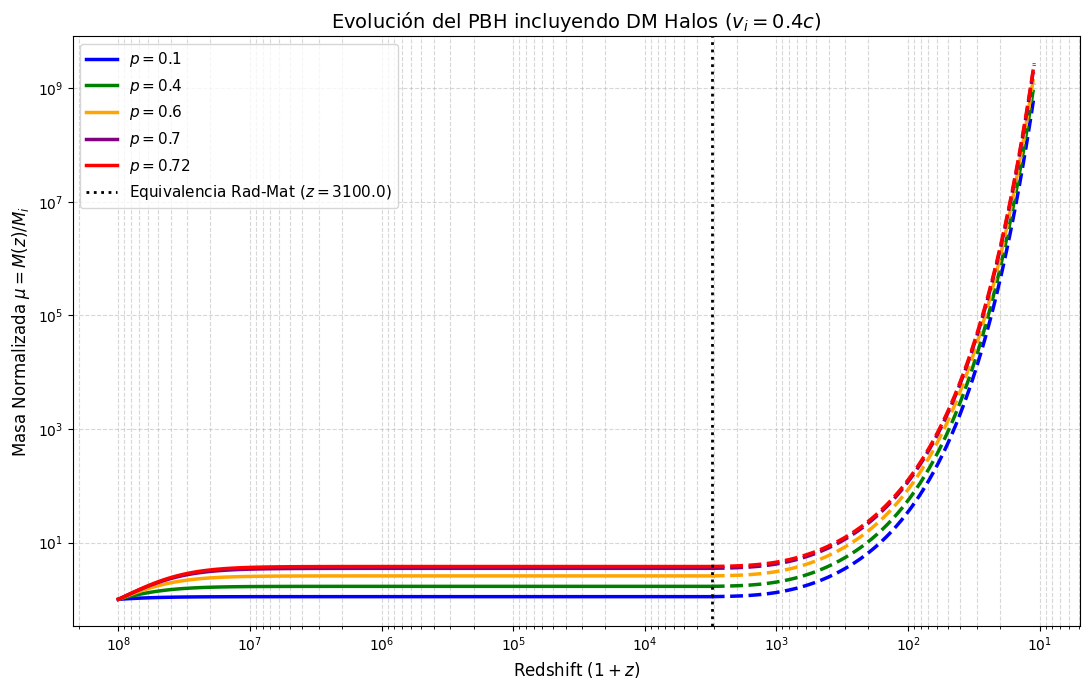

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

# =========================================================
# 0. Constantes Globales y Cosmológicas (CGS)
# =========================================================
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
M_sol = 1.989e33
m_H = 1.67e-24        
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_m0 = 0.32       
Omega_r0 = 9.4e-5     
Omega_L0 = 0.68       

K = (hbar * c**4) / (3840 * np.pi * G**2)

# --- FÍSICA DE LA MATERIA OSCURA ---
Omega_cdm = 0.85 * Omega_m0 
rho_c0 = 3 * H0**2 / (8 * np.pi * G)
z_eq = 3100.0
rho_eq = 2 * rho_c0 * Omega_m0 * (1 + z_eq)**3
# Tiempo cósmico en la igualdad materia-radiación
t_eq = (4.0 / 3.0) * (np.sqrt(2) - 1.0) / (H0 * np.sqrt(Omega_m0) * (1 + z_eq)**1.5)

# =========================================================
# 1. Parámetros de Simulación Base
# =========================================================
z_i = 1e8
z_f_rad = z_eq

p_array = [0.1, 0.4, 0.6, 0.7, 0.72]
colores = ['blue', 'green', 'orange', 'purple', 'red']

c_s_rad = c / np.sqrt(3)
t_i = 1.0 / (2 * H0 * np.sqrt(Omega_r0) * (1 + z_i)**2)
M_Hi = (c**3 * t_i) / G
v_pbh_inicial = 0.4*c 

# =========================================================
# 2. Funciones de Halos de Materia Oscura (Sección 3.1)
# =========================================================
def DM_halo_properties(M_pbh, z):
    """Calcula la masa del halo de Materia Oscura y su radio de Turnaround."""
    # Tiempo cósmico en la era de materia
    t_z = (2.0 / 3.0) / (H0 * np.sqrt(Omega_m0) * (1 + z)**1.5)
    
    # Eq 3.14: Radio de Turnaround
    r_ta = (2 * G * M_pbh * t_z**2)**(1.0/3.0)
    
    # Eq 3.13: Densidad media del halo
    rho_bar = (Omega_cdm / Omega_m0) * (rho_eq / 2.0) * (2 * G * M_pbh * t_eq**2)**0.75 * r_ta**(-2.25)
    
    # Eq 3.16: Masa total del halo (con alpha = 9/4 -> 3-alpha = 0.75)
    M_h = (4 * np.pi * rho_bar / 0.75) * r_ta**3
    
    return M_h, r_ta

def get_effective_bondi_radius(M_pbh, v_eff, z):
    """Resuelve analíticamente el radio de Bondi efectivo en presencia del Halo."""
    M_h, r_ta = DM_halo_properties(M_pbh, z)
    
    r_B_iso = G * M_pbh / v_eff**2             # Límite inferior (sin halo)
    r_B_max = G * (M_pbh + M_h) / v_eff**2     # Límite superior (halo completo puntual)
    
    # Eq 3.21: Si el radio de Bondi contiene todo el halo
    if r_B_max >= r_ta:
        return r_B_max, M_h
        
    # Eq 3.22: Si el radio de Bondi cae DENTRO del halo extendido, resolvemos la raíz
    def bondi_root(r):
        term_pbh = G * M_pbh / r
        term_halo = (G * M_h / (r * 0.25)) * ((r / r_ta)**0.75 - 0.75 * (r / r_ta))
        return term_pbh + term_halo - v_eff**2

    try:
        # Encontramos la raíz exacta entre los dos límites físicos
        r_B_eff = brentq(bondi_root, r_B_iso, r_B_max)
    except ValueError:
        r_B_eff = r_B_iso # Fallback de seguridad numérica
        
    return r_B_eff, M_h

# =========================================================
# 3. Funciones Cinemáticas y de Eficiencia
# =========================================================
def cosmic_velocities_mat(z):
    c_s = 6e5 * np.sqrt((1 + z) / 1000.0)
    factor = min(1.0, (1 + z) / 1000.0)
    v_pbh = 30e5 * factor
    v_eff = np.sqrt(v_pbh**2 + c_s**2)
    return c_s, v_pbh, v_eff

def lambda_efficiency(z, M_total, v_eff):
    # Nota: M_total debe incluir la masa del PBH + Masa del Halo
    x_e = 1e-3 
    v_eff_km_s = v_eff / 1e5
    term1 = (M_total / (1e4 * M_sol))
    term2 = ((1 + z) / 1000.0)**1.5
    term3 = (v_eff_km_s / 5.74)**(-3)
    term4 = 0.257 + 1.45 * (x_e / 0.01) * ((1 + z) / 1000.0)**2.5
    beta_hat = term1 * term2 * term3 * term4
    
    if beta_hat < 1e-12:
        return 1.0
    
    x_cr = (-1.0 + np.sqrt(1.0 + beta_hat)) / beta_hat
    lam = np.exp(4.5 / (3.0 + beta_hat**0.75)) * (x_cr**2)
    return lam

def evaporacion_total(t, y):
    return y[0] - 1e-3
evaporacion_total.terminal = True
evaporacion_total.direction = -1

# =========================================================
# 4. Simulación Principal
# =========================================================
plt.figure(figsize=(11, 7))

print("-" * 55)
print("SIMULACIÓN BHL CON HALOS DE MATERIA OSCURA INTEGRADOS")
print("-" * 55)

for p_val, color in zip(p_array, colores):
    M_i_val = p_val * M_Hi
    E_val = (2 * K * t_i) / (M_i_val**3)
    
    print(f"-> Simulando p = {p_val} (M_i = {M_i_val:.2e} g)")
    
    # --- FASE 1: RADIACIÓN ---
    def dmu_dv_rad(v, mu):
        mu_val = np.atleast_1d(mu)[0]
        if mu_val <= 1e-5: return [0.0]
        
        v_pbh_actual = v_pbh_inicial * v
        v_eff = np.sqrt(c_s_rad**2 + v_pbh_actual**2)
        f_dinamico = (8 * np.sqrt(2) / 3) * (v_eff / c)**3
        
        term_evap = E_val / ((v**3) * (mu_val**2))
        term_acc = (2 * p_val / f_dinamico) * (mu_val**2) * v
        return [term_evap - term_acc]

    sol_rad = solve_ivp(dmu_dv_rad, [1.0, (1.0 + z_f_rad)/(1.0 + z_i)], [1.0],       
                        method='Radau', events=evaporacion_total, rtol=1e-8, atol=1e-10)

    v_sol_rad = sol_rad.t
    l_plus_z_rad = v_sol_rad * (1.0 + z_i)
    mu_sol_rad = sol_rad.y[0]
    
    plt.loglog(l_plus_z_rad, mu_sol_rad, color=color, lw=2.5, label=f'$p={p_val}$')
    
    # --- FASE 2: MATERIA (BHL CON HALO DE DM) ---
    if sol_rad.status != 1 and mu_sol_rad[-1] >= 1e-2:
        M_start_mat = mu_sol_rad[-1] * M_i_val
        
        def dM_dz_mat(z, M):
            M_val = np.atleast_1d(M)[0]
            if M_val <= 1e-5: return [0.0]
            
            n_gas = 200.0 * ((1 + z) / 1000.0)**3    
            rho_b = m_H * n_gas                      
            c_s, v_pbh, v_eff = cosmic_velocities_mat(z)
            
            # ¡FÍSICA NUEVA APLICADA AQUÍ!
            r_B_eff, M_h = get_effective_bondi_radius(M_val, v_eff, z)
            lam = lambda_efficiency(z, M_val + M_h, v_eff) # La eficiencia evalúa la masa conjunta
            
            dM_dt_acc = 4 * np.pi * lam * rho_b * v_eff * (r_B_eff**2)
            dM_dt_evap = K / (M_val**2)
            dM_dt_total = dM_dt_acc - dM_dt_evap
            
            H_z = H0 * np.sqrt(Omega_r0*(1+z)**4 + Omega_m0*(1+z)**3 + Omega_L0)
            dt_dz = -1.0 / ((1 + z) * H_z)
            
            return [dM_dt_total * dt_dz]

        sol_mat = solve_ivp(dM_dz_mat, [z_f_rad, 10.0], [M_start_mat],
                            method='Radau', events=evaporacion_total, rtol=1e-8, atol=1e-10)
        
        z_sol_mat = sol_mat.t
        M_sol_mat = sol_mat.y[0]
        
        if sol_mat.status == 1 and M_sol_mat[-1] < 1e-2:
            z_sol_mat = np.append(z_sol_mat, z_sol_mat[-1] - 1e-6)
            M_sol_mat = np.append(M_sol_mat, np.nan)

        l_plus_z_mat = 1.0 + z_sol_mat
        mu_sol_mat = M_sol_mat / M_i_val
        
        plt.loglog(l_plus_z_mat, mu_sol_mat, color=color, lw=2.5, linestyle='--')

# =========================================================
# 5. Estética de la Gráfica
# =========================================================
plt.gca().invert_xaxis()
plt.xlabel(r'Redshift $(1+z)$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M(z)/M_{i}$', fontsize=12)
plt.title(f'Evolución del PBH incluyendo DM Halos ($v_i={v_pbh_inicial/c}c$)', fontsize=14)

plt.axvline(x=z_f_rad, color='black', linestyle=':', lw=2, label=f'Equivalencia Rad-Mat ($z={z_f_rad}$)')
plt.grid(True, which="both", linestyle='--', alpha=0.5)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=11, loc='best')

plt.tight_layout()
plt.show()